
# Batch Predict + Metrics & Confusion Matrix

This notebook:
- Loads a **Lightning checkpoint** for `IrrMLPClassifier`  
- Applies it to a set of CSVs (glob) with AlphaEarth features  
- If labels are present, computes **AUROC**, **AUPRC**, **ROC**/**PR** curves, and a **confusion matrix** at a chosen threshold  
- Gives per-year and per-county summaries

> **Notes**
> - Update the config cell with your `CKPT_PATH` and `DATA_GLOB`.
> - The code supports **CPU**, **CUDA**, and **Apple MPS** (M1/M2).


In [ ]:

# Imports
from pathlib import Path
import glob
import re
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    classification_report,
)

from irr.models.mlp_classifier import IrrMLPClassifier, ModelConfig
from irr.constants import FEATURES, LABEL_COL


In [ ]:
import glob, os

run_dirs = glob.glob("../outputs/logs/mlp_classifier_tb/version_10")
assert run_dirs, "No runs found"
latest_run = max(run_dirs, key=os.path.getmtime)

ckpts = glob.glob(os.path.join(latest_run, "checkpoints", "*.ckpt"))
assert ckpts, f"No checkpoints in {latest_run}"
CKPT_PATH = max(ckpts, key=os.path.getmtime)
print("Using ckpt:", os.path.normpath(CKPT_PATH))


# ==== User Config ====

CKPT_PATH = max(ckpts, key=os.path.getmtime) # <-- set me
DATA_GLOB = "../raw_data/WA*.csv"                                                  # <-- set me
OUT_CSV   = "notebooks/predictions/preds_all.csv"                             # where to save predictions
THRESHOLD = 0.944                                                               # decision threshold
BATCH_SIZE = 256
DEVICE = "mps"


Using ckpt: ../outputs/logs/mlp_classifier_tb/version_10/checkpoints/026-0.0635.ckpt


'mps'

In [50]:

# Load CSVs (keep all columns; require FEATURES present)
paths = sorted(glob.glob(DATA_GLOB))
if not paths:
    raise FileNotFoundError(f"No CSV files matched: {DATA_GLOB}")

dfs = []
for p in paths:
    df = pd.read_csv(p)
    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise ValueError(f"{p} missing feature columns: {missing}")
    df["_source_path"] = p  # keep origin for summaries
    dfs.append(df)

full = pd.concat(dfs, ignore_index=True)
full = full.dropna(subset=FEATURES).reset_index(drop=True)
print(f"Loaded {len(paths)} files → combined shape: {full.shape}")
full.head(3)


Loaded 5 files → combined shape: (94827, 74)


,system:index,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A63,cdl_code,county,county_fips,county_name,label,state,year,.geo,_source_path
0,0,-0.199862,-0.206936,-0.024606,-0.038447,0.113741,0.055363,0.103406,-0.084214,0.084214,...,-0.113741,122,<Feature>,11,Clark,0,WA,2018,"{""type"":""Point"",""coordinates"":[-122.4564466986...",../raw_data/WA_alphaearth_irrmapper_training_2...
1,1,0.038447,-0.172795,-0.062991,-0.130165,0.119093,0.019931,0.012057,-0.038447,0.015748,...,-0.059116,142,<Feature>,47,Okanogan,0,WA,2018,"{""type"":""Point"",""coordinates"":[-119.2385512939...",../raw_data/WA_alphaearth_irrmapper_training_2...
2,2,-0.124567,-0.048228,0.012057,-0.059116,-0.048228,-0.172795,-0.027128,0.172795,0.113741,...,0.059116,1,<Feature>,21,Franklin,1,WA,2018,"{""type"":""Point"",""coordinates"":[-119.3194910744...",../raw_data/WA_alphaearth_irrmapper_training_2...


In [ ]:
# ---- Load model ----
model = IrrMLPClassifier.load_from_checkpoint(
    CKPT_PATH, cfg=ModelConfig(), strict=False, map_location="cpu"
).eval().to(DEVICE)

# Use tuned threshold if calibration is available; else fallback
use_cal = bool(model.use_calibration.item())
thr = float(model.best_threshold.item()) if use_cal else THRESHOLD

# ---- DataLoader ----
X = torch.as_tensor(full[FEATURES].values, dtype=torch.float32)
ds = TensorDataset(X)
pin = (DEVICE == "cuda")
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)

# ---- Inference (calibrated) ----
probs_cal_list, logits_raw_list, probs_raw_list = [], [], []  # raw are optional
model.eval()
with torch.no_grad():
    for (xb,) in dl:
        xb = xb.to(DEVICE, non_blocking=pin)
        # raw logits
        logits = model(xb)                      # (B,)
        # calibrated probs
        p_cal = model.predict_proba(xb)         # applies T,b inside
        probs_cal_list.append(p_cal.cpu())

        # (optional) keep raw for inspection
        logits_raw_list.append(logits.cpu())
        probs_raw_list.append(torch.sigmoid(logits).cpu())

probs_cal = torch.cat(probs_cal_list).numpy()          # (N,)
logits_raw = torch.cat(logits_raw_list).numpy()        # (N,)
probs_raw  = torch.cat(probs_raw_list).numpy()         # (N,)

# ---- Build output ----
preds_df = full.copy()
preds_df["logit_raw"]         = logits_raw
preds_df["prob_raw"]          = probs_raw
preds_df["prob_irrigated"]    = probs_cal               # calibrated is the default now
preds_df["pred_irrigated"]    = (probs_cal >= thr).astype(int)
preds_df["used_threshold"]    = thr
preds_df["used_calibration"]  = int(use_cal)

# ---- Save ----
out_path = Path(OUT_CSV)
out_path.parent.mkdir(parents=True, exist_ok=True)
preds_df.to_csv(out_path, index=False)
print(f"Wrote predictions to {out_path.resolve()}")
print(f"Rows: {len(preds_df):,} | Threshold: {thr:.3f} | Calibrated: {use_cal} | Device: {DEVICE}")



/Users/tim/repos/pytorch_irr_model_modular/.venv/lib/python3.12/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['loss.pos_weight']


Wrote predictions to /Users/tim/repos/pytorch_irr_model_modular/notebooks/notebooks/predictions/preds_all.csv
Rows: 94,827 | Threshold: 0.944 | Device: mps


,system:index,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,county_fips,county_name,label,state,year,.geo,_source_path,logit_irrigated,prob_irrigated,pred_irrigated
0,0,-0.199862,-0.206936,-0.024606,-0.038447,0.113741,0.055363,0.103406,-0.084214,0.084214,...,11,Clark,0,WA,2018,"{""type"":""Point"",""coordinates"":[-122.4564466986...",../raw_data/WA_alphaearth_irrmapper_training_2...,3.507200,0.970892,1
1,1,0.038447,-0.172795,-0.062991,-0.130165,0.119093,0.019931,0.012057,-0.038447,0.015748,...,47,Okanogan,0,WA,2018,"{""type"":""Point"",""coordinates"":[-119.2385512939...",../raw_data/WA_alphaearth_irrmapper_training_2...,-12.398205,0.000004,0
2,2,-0.124567,-0.048228,0.012057,-0.059116,-0.048228,-0.172795,-0.027128,0.172795,0.113741,...,21,Franklin,1,WA,2018,"{""type"":""Point"",""coordinates"":[-119.3194910744...",../raw_data/WA_alphaearth_irrmapper_training_2...,7.432321,0.999409,1


In [52]:

# Metrics (if labels are present)
has_labels = LABEL_COL in preds_df.columns
if has_labels:
    y_true = preds_df[LABEL_COL].astype(int).values
    y_prob = preds_df["prob_irrigated"].values
    y_pred = (y_prob > THRESHOLD).astype(int)

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    print(f"AUROC: {auroc:.4f}  |  AUPRC: {auprc:.4f}")

    # Confusion matrix at current threshold
    cm = confusion_matrix(y_true, y_pred)  # [[TN, FP], [FN, TP]]
    print(f"Confusion matrix (thr = {THRESHOLD:.3f}):\n{cm}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

else:
    print("No labels found in data; skipping metrics.")


AUROC: 0.9933  |  AUPRC: 0.9333
Confusion matrix (thr = 0.944):
[[88907   536]
 [  939  4445]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9895    0.9940    0.9918     89443
           1     0.8924    0.8256    0.8577      5384

    accuracy                         0.9844     94827
   macro avg     0.9410    0.9098    0.9247     94827
weighted avg     0.9840    0.9844    0.9842     94827



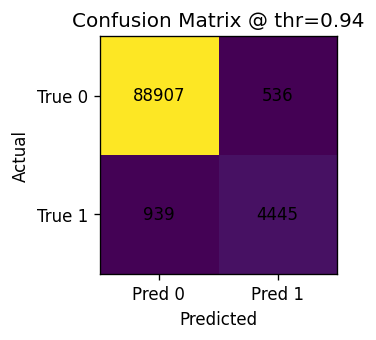

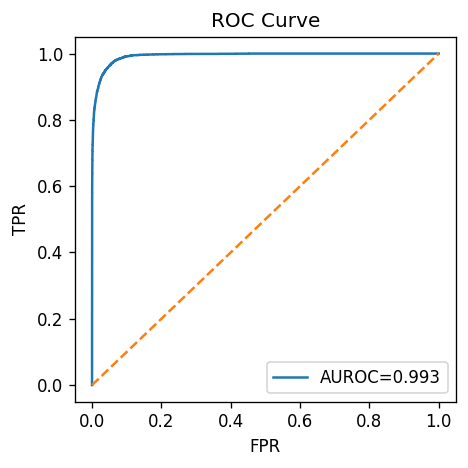

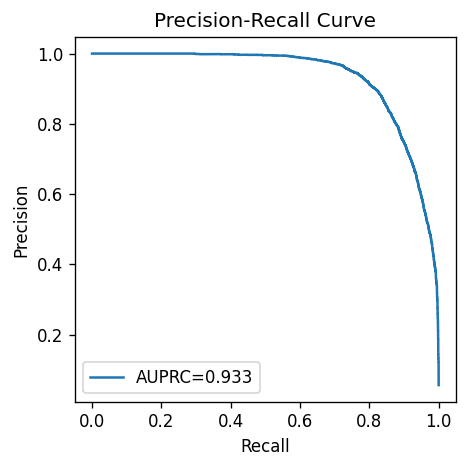

In [53]:

# Plots
if has_labels:
    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(3,3), dpi=120)
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"Confusion Matrix @ thr={THRESHOLD:.2f}")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred 0","Pred 1"])
    ax.set_yticklabels(["True 0","True 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(int(cm[i, j])), ha="center", va="center")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    fig.tight_layout()
    plt.show()

    # ROC
    from sklearn.metrics import roc_curve, precision_recall_curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(4,4), dpi=120)
    plt.plot(fpr, tpr, label=f"AUROC={auroc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Precision-Recall
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(4,4), dpi=120)
    plt.plot(rec, prec, label=f"AUPRC={auprc:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [54]:

# Best-F1 threshold
if has_labels:
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = (2 * prec[:-1] * rec[:-1]) / np.maximum(prec[:-1] + rec[:-1], 1e-9)
    best_idx = int(np.argmax(f1))
    best_thr = float(thr[best_idx])
    print(f"Best F1 at threshold ~ {best_thr:.3f}  (P={prec[best_idx]:.2f}, R={rec[best_idx]:.2f})")


Best F1 at threshold ~ 0.944  (P=0.89, R=0.83)


In [55]:

# Per-year & per-county breakdowns
if "year" not in preds_df.columns:
    preds_df["year"] = preds_df["_source_path"].astype(str).apply(
        lambda s: int(re.search(r"20\d{2}", s).group()) if re.search(r"20\d{2}", s) else -1
    )

if has_labels:
    by_year = preds_df.groupby("year")[LABEL_COL].value_counts().unstack(fill_value=0).sort_index()
    print("\nLabel counts by year (head):")
    display(by_year.head(10))

county_col = None
for cand in ["county", "county_name", "county_fips"]:
    if cand in preds_df.columns:
        county_col = cand
        break

if county_col:
    if has_labels:
        by_county = preds_df.groupby(county_col)[LABEL_COL].value_counts().unstack(fill_value=0)
        print("\nLabel counts by county (head):")
        display(by_county.head(10))

        def cm_counts(g: pd.DataFrame):
            yt = g[LABEL_COL].astype(int).values
            yp = (g["prob_irrigated"].values > THRESHOLD).astype(int)
            tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
            return pd.Series(dict(TN=tn, FP=fp, FN=fn, TP=tp, support=len(g)))

        county_cm = preds_df.groupby(county_col).apply(cm_counts).sort_values("support", ascending=False)
        print("\nPer-county confusion counts (head):")
        display(county_cm.head(10))
    else:
        print("\nNo labels found, showing raw predicted counts per county:")
        pred_counts = preds_df.groupby(county_col)["pred_irrigated"].value_counts().unstack(fill_value=0)
        display(pred_counts.head(10))
else:
    print("\nNo county column found; skipping county breakdowns.")



Label counts by year (head):


label,0,1
year,,
2018,17835,1096
2019,17822,1112
2020,17913,1086
2021,17934,1063
2022,17939,1027



Label counts by county (head):


label,0,1
county,,
<Feature>,89443,5384



Per-county confusion counts (head):


/var/folders/30/ts9qnzxs1p90140qbxntdc7m0000gn/T/ipykernel_3200/2872330968.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  county_cm = preds_df.groupby(county_col).apply(cm_counts).sort_values("support", ascending=False)


,TN,FP,FN,TP,support
county,,,,,
<Feature>,88907,536,939,4445,94827
